# Second review round: boundary-free re-fabrication, seeds, emitter efficiency and a trajectory check of the readout

In [1]:
import os, sys, subprocess, numpy as np
CODE = os.path.abspath(os.path.join(os.getcwd(), '..', 'code')); sys.path.insert(0, CODE); os.chdir(CODE); os.environ['OMP_NUM_THREADS'] = '1'
import matplotlib; matplotlib.use('Agg')
from IPython.display import Image, display
RUN = False   # set True to recompute the data of this notebook (cost given in each Compute section)
def show(pdf, dpi=110):
    base = '/tmp/' + os.path.basename(pdf)[:-4]; subprocess.run(['pdftoppm', '-r', str(dpi), '-png', '-singlefile', pdf, base], check=True); display(Image(filename=base + '.png'))
ld = lambda n: np.load(os.path.join('data', n), allow_pickle=True)
pc = lambda a, b: 100 * (1 - a / b)
TASKS = ['mg', 'narma', 'lorenz', 'nce', 'laser']

## Questions of the second review
1. **Boundary artefact.** Several re-fabricated optima of `rev_refab.py` touch the search box (NARMA10 $g=1.20$, Lorenz $\epsilon=1.596$, channel equalization $\kappa=0.99$, Mackey–Glass $\omega_a,\omega_q=2.0$), and squeezing rescales $g_{\rm co}=g\cosh r$ beyond the face (NARMA10: $1.20\cosh0.241=1.235$). Is the gain of squeezing on the re-fabricated device a gain of squeezing, or of leaving the box?
2. **Seeds.** Do the tuned-drive headline gains (NARMA10, channel equalization) survive fresh input realizations?
3. **Emitter detection efficiency.** The emitter channel dominates the readout cost; how do the conclusions change for $\eta_e=0.3, 0.1$?
4. **Readout model.** The cost section uses a bin model (single-time variance + white detector noise, within-bin input–field correlation neglected). Is it right?

## 1. Wide-box re-fabrication, squeezing on it, and a joint search (`rev_bounds.py`, `rev_bounds2*.py`)
`rev_bounds.py` runs the study below with the paper's noiseless objective; its ordinary stage (NARMA10, channel equalization) exposed the weak-signal problem, and the study was completed with the measurement-aware objective in an even wider box by `rev_bounds2.py` ($g\in[0.005,3]$, $\kappa\in[0.005,3]$, $\gamma\in[0.002,2]$, $\omega_{a,q}\in[0,5]$, $\epsilon\in[0.001,5]$; ordinary 506 evaluations; sequential = 300 + 206; joint 506), `rev_bounds2_final.py` (squeezing on the converged ordinary optimum), `rev_bounds2_jointzero.py`, `rev_bounds2_jointlocal.py` and `rev_bounds2_budget.py` (Lorenz, photon budget 4). The stages as first designed:
Per task, with photon budget 2.5 and $N_c=10$ (optima checked at $N_c=14$, and $18$ near the budget):
* **sanity check** – old re-fabricated optimum with $g\to g\cosh r_{\rm sq}$ and the drive $(\epsilon\le5,\delta)$ re-tuned, no squeezing;
* **ordinary** – $(g,\kappa,\gamma,\omega_a,\omega_q,\epsilon)$ in $g\in[0.02,3]$, $\kappa\in[0.01,3]$, $\gamma\in[0.005,2]$, $\omega_{a,q}\in[0,3]$, $\epsilon\in[0.01,5]$; 200-point Latin hypercube + the old optimum, Nelder–Mead from the three best distinct points, continuation; 706 evaluations;
* **sequential** – squeezing search of Sec. 2.4 ($2\times72$ scan + 60 convergent-descent evaluations) from the ordinary optimum after 500 evaluations: 706 evaluations in total, the same as *ordinary*;
* **matched** – squeezing on the ordinary optimum with $\Omega_a$, $g\cosh r$ and $\epsilon_{\rm eff}$ pinned to their unsqueezed values ($\omega_a\to\omega_a\cosh2r$, $g\to g/\cosh r$, $\epsilon\to\epsilon/\sqrt{\cosh2r-\sinh2r\cos2\phi_d}$): only $g\sinh r$ and the phase-sensitive damping can act;
* **mapped** – unsqueezed device with the effective parameters of the sequential optimum, then Nelder–Mead over all six parameters (120 evaluations);
* **joint** – all ten parameters $(g,\kappa,\gamma,\omega_a,\omega_q,\epsilon,r,r_e,\Delta\theta,\phi_d)$ from scratch, same protocol and budget (706) as *ordinary*.

### Compute (≈ 45 min per task on one core; run two tasks in parallel)

In [2]:
if RUN:   # ~45 min per task and stage set on one core; run tasks in parallel processes
    for s in (['rev_bounds.py', 'narma', 'nce'], ['rev_bounds2.py', 'narma', 'lorenz', 'mg'], ['rev_bounds2.py', 'nce', 'laser'],
              ['rev_bounds2_final.py', 'mg', 'narma', 'lorenz', 'nce', 'laser'], ['rev_bounds2_jointzero.py', 'mg', 'narma', 'lorenz', 'nce', 'laser'],
              ['rev_bounds2_jointlocal.py', 'nce'], ['rev_bounds2_budget.py']):
        subprocess.run([sys.executable, *s], check=True)

### Results

In [3]:
PN = ['g', 'kappa', 'gamma', 'omega_a', 'omega_q', 'eps']
for n in ('narma', 'nce'):                                   # noiseless objective, wide box: where the optimum goes
    d = ld(f'rev_bounds_{n}.npz'); T = d['ord_trace']; ok = T[:, 12] <= 2.5; b = T[ok][T[ok, 10].argmin()]
    print(f'{n}: noiseless objective, wide box ->', dict(zip(PN, b[:6].round(4))), 'L %.4e, max photons %.1e' % (b[10], b[12]))
print()
for n in TASKS:                                              # measurement-aware objective
    d = ld(f'rev_bounds2_{n}.npz'); q = ld(f'rev_bounds2_{n}_sqf.npz'); c = lambda k: d[k][-1][0]
    o, j = d['ord_best'], d['joint_best']; R = d['refs'][:, 0]
    print(f'--- {n}: tuned base {R[0]:.4e}, tuned+sq {R[1]:.4e}, old-box refab {R[2]:.4e}, old-box refab+sq {R[3]:.4e}')
    print('  wide-box ordinary', dict(zip(PN, o[:6].round(3))), 'nmax %.2f  L %.4e (checked %.4e)' % (o[12], o[10], c('chk_ord')))
    print('  squeezing on it: theta', q['best'][6:9].round(3), 'phi_d %.2f  L %.4e (checked %.4e, %+.2f%%)' % (q['best'][9], q['best'][10], q['chk'][-1][0], -pc(q['chk'][-1][0], q['chk0'][-1][0])))
    print('  matched %.4e   sequential (300+206) %.4e   joint %.4e (%+.1f%%)' % (d['mat_best'][10], d['seq_best'][10], j[10], -pc(c('chk_joint'), c('chk_ord'))))
jz, jl = ld('rev_bounds2_nce_jointzero.npz'), ld('rev_bounds2_nce_jointlocal.npz')
print('\nchannel eq.: joint device unsqueezed %.4e; ordinary re-optimized from it %.4e' % (jz['L'][0], jl['best'][10]))
bu = ld('rev_bounds2_lorenz_budget.npz'); print('Lorenz, photon budget 4: ordinary %.4e, squeezed (best of two starts)' % bu['ord_best'][10], bu['sq'][:, 4], 'N_c=20:', bu['chk20'][:, 0])

narma: noiseless objective, wide box -> {'g': np.float64(0.3033), 'kappa': np.float64(0.1167), 'gamma': np.float64(0.0806), 'omega_a': np.float64(2.871), 'omega_q': np.float64(0.0008), 'eps': np.float64(0.0103)} L 1.7029e-03, max photons 9.2e-05
nce: noiseless objective, wide box -> {'g': np.float64(0.0201), 'kappa': np.float64(1.2848), 'gamma': np.float64(0.4842), 'omega_a': np.float64(0.7106), 'omega_q': np.float64(1.4847), 'eps': np.float64(0.0308)} L 2.5511e-02, max photons 1.2e-03

--- mg: tuned base 9.6631e-03, tuned+sq 9.7893e-03, old-box refab 5.2024e-03, old-box refab+sq 4.2819e-03
  wide-box ordinary {'g': np.float64(0.971), 'kappa': np.float64(0.105), 'gamma': np.float64(0.09), 'omega_a': np.float64(2.478), 'omega_q': np.float64(1.716), 'eps': np.float64(1.503)} nmax 0.66  L 7.2637e-04 (checked 7.2638e-04)
  squeezing on it: theta [ 0.     0.01  -3.142] phi_d 1.57  L 7.2619e-04 (checked 7.2620e-04, -0.02%)
  matched 7.2619e-04   sequential (300+206) 2.4207e-03   joint 1.1820

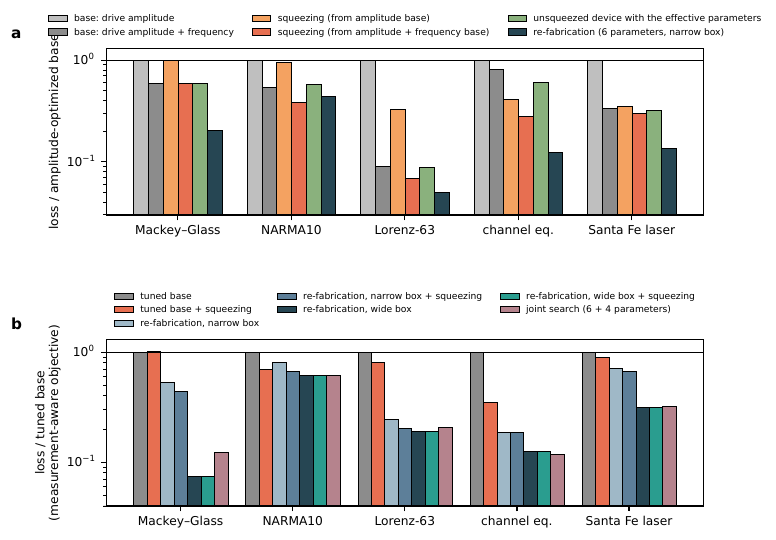

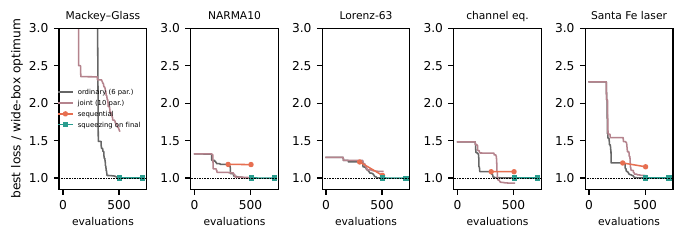

In [4]:
subprocess.run([sys.executable, 'make_rev.py'], check=True, capture_output=True)
show('../paper/figs/fig_refab.pdf'); show('../paper/figs/figS_bounds.pdf')

For reference, squeezing on the re-fabricated optimum of the **original** box (`rev_refab_sq.py`, `rev_refab_sq14.py`), the study the wide box supersedes:

In [5]:
print(open('../paper/refabsqtable.tex').read())

\begin{tabular}{lccccc}
\toprule
task & $\phi_d$ & $(r,\re,\dth)$ & $\Lc$ re-fabricated & $\Lc$ + squeezing & $N_c$\\
\midrule
Mackey--Glass & $\pi/2$ & (0.01, 0.15, 3.13) & \ensuremath{1.34\times10^{-3}} & \ensuremath{1.31\times10^{-3}} (-3\%) & 18\\
NARMA10 & $\pi/2$ & (0.24, 0.50, -3.14) & \ensuremath{2.21\times10^{-3}} & \ensuremath{1.72\times10^{-3}} (-22\%) & 14\\
Lorenz-63 & 0 & (0.00, 0.31, -0.03) & \ensuremath{4.63\times10^{-3}} & \ensuremath{3.86\times10^{-3}} (-17\%) & 18\\
channel eq. & $\pi/2$ & (0.03, 0.50, 0.69) & \ensuremath{3.04\times10^{-2}} & \ensuremath{3.05\times10^{-2}} (+0\%) & 14\\
Santa Fe laser & 0 & (0.05, 0.02, 3.14) & \ensuremath{2.88\times10^{1}} & \ensuremath{2.62\times10^{1}} (-9\%) & 14\\
\bottomrule
\end{tabular}


## 2. Fresh realizations (`rev_seeds.py`, ≈ 35 min)
Eight new realizations (seeds 1–8) of NARMA10 and channel equalization. (a) The paper's tuned base and squeezed setting evaluated unchanged; (b) the drive re-tuned (30 Nelder–Mead evaluations) and the squeezing controls re-optimized (60 convergent-descent evaluations) on each realization.

In [6]:
if RUN: subprocess.run([sys.executable, 'rev_seeds.py'], check=True)
print(open('../paper/seedtable.tex').read())
sd = ld('rev_seeds.npz')
for n in ('narma', 'nce'):
    R = np.array([sd[f'{n}_{s}_reopt'] for s in range(1, 9) if f'{n}_{s}_reopt' in sd.files])
    print(n, 'gain per seed (%):', (100 * R[:, 3]).round(1))

\begin{tabular}{lcccc}
\toprule
task & gain, seed 0 (paper) & gain, re-optimized, seeds 1--8 & range & gain, settings transferred\\
\midrule
NARMA10 & 28\% & $26\pm4$\% & 20--31\% & $26\pm4$\%\\
channel eq. & 66\% & $65\pm3$\% & 63--70\% & $66\pm2$\%\\
\bottomrule
\end{tabular}
narma gain per seed (%): [25.5 25.6 20.2 29.7 21.3 26.9 30.7 31.3]
nce gain per seed (%): [64.4 62.9 70.2 65.  62.8 67.4 63.  66.4]


## 3. Emitter detection efficiency (`rev_etae.py`, ≈ 2 min)
The measured-gain calculation of Fig. 3a repeated for $\eta_e=0.5,0.3,0.1$. Last column: factor by which the passes needed for a given median precision grow (median over the ten operating points).

In [7]:
if RUN: subprocess.run([sys.executable, 'rev_etae.py'], check=True)
print(open('../paper/etatable.tex').read())

\begin{tabular}{lccccccccc}
\toprule
$\eta_e$ & \multicolumn{2}{c}{NARMA10} & \multicolumn{2}{c}{Lorenz-63} & \multicolumn{2}{c}{channel eq.} & \multicolumn{2}{c}{Santa Fe laser} & passes for $\sigma_{\rm rel}=1\%$\\
 & $10^6$ & $10^7$ & $10^6$ & $10^7$ & $10^6$ & $10^7$ & $10^6$ & $10^7$ & (relative to $\eta_e=0.5$)\\
\midrule
0.5 & 18 & 27 & 5 & 12 & 51 & 63 & -5 & 4 & 1.0\\
0.3 & 14 & 25 & 4 & 16 & 47 & 62 & -5 & -2 & 1.5\\
0.1 & 12 & 24 & 3 & 11 & 33 & 57 & -5 & -3 & 3.8\\
\bottomrule
\end{tabular}


## 4. Quantum trajectories of the homodyne currents (`rev_sme.py`, ≈ 15 min)
**Exact vacuum representation of the squeezed bath.** $\mathcal D[L_a]$ with $L_a=\sqrt\kappa(\mu a+\nu a^\dagger)$ is generated by a vacuum field $b_0$ through $b_{\rm in}=\mu b_0-\nu b_0^\dagger$; then $b_{0,\rm out}=\mu b_{\rm out}+\nu b_{\rm out}^\dagger=b_0+L_a$, and homodyne detection of the physical quadrature $x_\Phi(b_{\rm out})$ is homodyne detection of $x_{\Phi'}(b_{0,\rm out})$ scaled by $A=\sqrt{V_{\rm in}(\Phi)}$ with $A\,x_{\Phi'}(L_a)=\sqrt\kappa\,x_\Phi(a)$; efficiency $\eta_c$ becomes $\eta'=\eta_cV_{\rm in}/(\eta_cV_{\rm in}+1-\eta_c)$.

**Simulation.** Stochastic Schrödinger equation with both channels unravelled by ideal homodyne detection (Itô–Euler, $dt=0.005$, check at $dt/2$); inefficiency added to the currents as independent white noise. 8,000 trajectories from pure states sampled from the unconditional state at symbol 300, 12 symbols. Estimators $\hat X=AJ_c/(\sqrt\kappa\tau)$, $\widehat{X^2}=\hat X^2-s_c$, $\hat\sigma=J_e/(\sqrt\gamma\tau)$, compared with the bin model per bin; then the loss noise of the full readout with covariances rescaled to the trajectory values.

\begin{tabular}{llcccc}
\toprule
point & setting & $\mathrm{Var}[\hat X]$ & $\mathrm{Var}[\widehat{X^2}]$ & $\mathrm{Cov}[\hat X,\widehat{X^2}]$ & $\mathrm{Var}[\hat\sigma]$\\
\midrule
tuned base & $(Q,\sigma_x)$ & 0.93 [0.92, 0.96] & 0.88 [0.84, 0.91] & 0.91 [0.18, 1.45] & 0.98 [0.97, 1.00]\\
tuned base & $(P,\sigma_y)$ & 0.93 [0.91, 0.96] & 0.87 [0.83, 0.93] & 0.92 [0.52, 1.67] & 0.98 [0.97, 1.00]\\
squeezed optimum & $(Q,\sigma_x)$ & 1.24 [1.22, 1.27] & 1.53 [1.46, 1.63] & 1.27 [0.32, 2.00] & 0.99 [0.97, 1.01]\\
 & \quad input-noise model & 0.93 & 0.87 & 0.95 & 0.99\\
squeezed optimum & $(P,\sigma_y)$ & 1.26 [1.23, 1.28] & 1.58 [1.49, 1.66] & 1.32 [0.77, 1.95] & 0.99 [0.97, 1.01]\\
 & \quad input-noise model & 0.93 & 0.86 & 0.98 & 0.99\\
\bottomrule
\end{tabular}


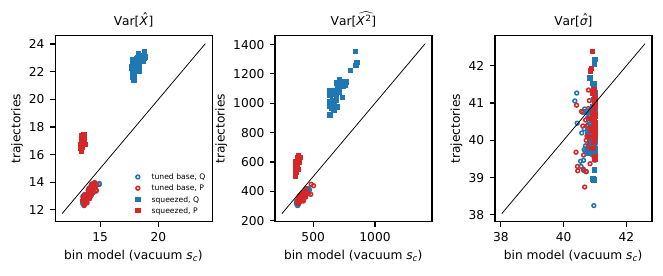

base clean L / bin-averaged [0.20284089 0.19966657]  rows [N, model mean, model std, traj-cal mean, traj-cal std]:
[[1.00000000e+05 2.11400793e-01 2.78286817e-03 2.11040690e-01
  2.85049908e-03]
 [1.00000000e+06 2.06154839e-01 1.76538151e-03 2.05553170e-01
  1.83848524e-03]
 [1.00000000e+07 2.03488871e-01 1.05799457e-03 2.03712362e-01
  1.36860986e-03]]
sq clean L / bin-averaged [0.0688858  0.05789974]  rows [N, model mean, model std, traj-cal mean, traj-cal std]:
[[1.00000000e+05 1.60948517e-01 4.72007241e-03 1.61109380e-01
  6.13834420e-03]
 [1.00000000e+06 1.02546144e-01 2.57470184e-03 1.01486057e-01
  3.10424366e-03]
 [1.00000000e+07 7.53613519e-02 1.12044045e-03 7.55798909e-02
  1.40149801e-03]]


In [8]:
if RUN: subprocess.run([sys.executable, 'rev_sme.py'], check=True)
print(open('../paper/smetable.tex').read())
show('../paper/figs/figS_sme.pdf')
s = ld('rev_sme.npz')
for k in ('base', 'sq'):
    print(k, 'clean L / bin-averaged', s[f'{k}_L0'], ' rows [N, model mean, model std, traj-cal mean, traj-cal std]:'); print(s[f'{k}_loss'])

## 6. Harder tasks (`rev_hard.py`, `rev_hard_conv.py`, `rev_hard_mg20b.py`, ≈ 20 min per level)
Does squeezing add more to a re-fabricated device when the task is harder for it? Difficulty ladders: Lorenz-63 2/5/10 steps ahead, Mackey–Glass 10/20/40 steps ahead, channel equalization of $d_{n-k}$ with $k=2/4/6$. Each new level: wide-box re-fabrication (measurement-aware objective, 506 evaluations), then squeezing on the optimum (206). Where squeezing gains more than 1 %, the ordinary search is extended (+450 evaluations) and squeezing repeated; Mackey–Glass 20 steps ahead also gets a second independent search.

\begin{tabular}{llccccc}
\toprule
 & & \multicolumn{2}{c}{NRMSE} & \multicolumn{3}{c}{loss reduction by squeezing (\%)}\\
\cmidrule(lr){3-4}\cmidrule(lr){5-7}
task & level & linear regression & re-fabricated & $\phi_d\in\{0,\pi/2\}$ & continuous phase & designed with the device\\
\midrule
Lorenz-63 & horizon 2 & 0.17 & 0.020 & 0.3 & 7.3 & 10.2\\
 & horizon 5 & 0.80 & 0.189 & 0.0 & 2.5 & 0.0\\
 & horizon 10 & 1.28 & 0.677 & 0.0 & 1.1 & 6.5\\
Mackey--Glass & horizon 10 & 0.43 & 0.187 & 0.0 & 0.4 & 5.3\\
 & horizon 20 & 0.61 & 0.107 & 2.9 & 3.0 & 8.5\\
 & horizon 40 & 0.83 & 0.304 & 2.0 & 4.2 & 9.1\\
channel eq. & delay 2 & 0.12 & 0.108 & 0.0 & 3.0 & 7.5\\
 & delay 4 & 0.12 & 0.149 & 0.1 & 0.1 & 0.0\\
 & delay 6 & 0.15 & 0.719 & 0.0 & 0.1 & 9.9\\
NARMA10 & -- & 0.84 & 0.570 & 0.1 & 0.1 & 0.0\\
Santa Fe laser & -- & 0.34 & 0.093 & 0.0 & 2.1 & 4.6\\
\bottomrule
\end{tabular}


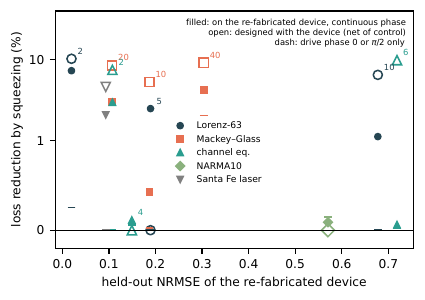

In [9]:
if RUN:
    subprocess.run([sys.executable, 'rev_hard.py', 'lorenz5', 'lorenz10', 'nce6'], check=True)
    subprocess.run([sys.executable, 'rev_hard.py', 'mg20', 'mg40', 'nce4'], check=True)
    subprocess.run([sys.executable, 'rev_hard_conv.py', 'mg20', 'mg40'], check=True); subprocess.run([sys.executable, 'rev_hard_mg20b.py'], check=True)
print(open('../paper/hardtable.tex').read())
show('../paper/figs/figS_hard.pdf')

**Result** (protocol of Sec. 2.4; continuous phases in section 7). No dependence on difficulty: squeezing the best re-fabricated device gains ≤ 2.9 % across eleven variants (rank correlation with the device NRMSE −0.17) and ≤ 0.15 % on the variants the device solves worst (Lorenz 10 steps, channel equalization 6 back, NARMA10), which exceed the memory of a single emitter. The exception is a joint design: Mackey–Glass 20 steps ahead, external squeezing alone ($r_e=0.34$) on the first re-fabricated device is 21 % below the best ordinary device found by three searches (1462 evaluations), while squeezing that best device gains 2.9 %.

## 7. Phase-sensitive terms at the re-fabricated optimum (`rev_ps.py`, ≈ 3 h on 2 cores)
Squeezing differs from re-fabrication only through its phase-sensitive terms. Here they are given to the ordinary device directly, in the lab frame (drive phase 0 as reference): a parametric term $-\frac{\lambda}{2}(e^{-i\phi_s}a^2+{\rm h.c.})$, the squeezed bath $(r_e,\Delta\theta)$ and an independent counter-rotating coupling $g_{\rm cr}(e^{i\phi_c}a\sigma+{\rm h.c.})$, all phases continuous. With $g_{\rm cr}=0$, $\lambda=\omega_a\tanh 2r$ this is the squeezed device with a continuous drive phase (`check`). At the best wide-box re-fabricated device: first-order response and knob search (`opt`); local redesign with the squeezing terms, the counter-rotating terms or none (control) (`decomp`); squeezing terms only with the device fixed, continuous phase (`sqfix`, `sqfix2`), and for the ladders squeezing + local redesign (`sqfix`) and its control (`ordctl`); the line from the tuned base to the re-fabricated device (`path`).

\begin{tabular}{lcccccc}
\toprule
 & \multicolumn{2}{c}{device fixed} & \multicolumn{4}{c}{device redesigned locally}\\
\cmidrule(lr){2-3}\cmidrule(lr){4-7}
task & squeezing & all terms & no terms (control) & squeezing & counter-rotating & all terms\\
\midrule
channel eq. & 3.0 & 3.5 & 0.2 & 7.6 & 5.2 & 11.0\\
NARMA10 & 0.1 & 0.1 & 0.3 & 0.2 & 0.1 & 0.1\\
Lorenz-63 & 7.3 & 7.2 & 0.6 & 10.8 & 0.3 & 7.4\\
Mackey--Glass & 0.4 & 3.4 & 1.1 & 6.3 & 25.6 & 22.7\\
Santa Fe laser & 2.1 & 2.0 & 0.0 & 4.6 & 5.3 & 4.2\\
Mackey--Glass (20 steps) & 3.0 & 3.0 & 0.1 & 8.6 & 10.8 & 2.7\\
\bottomrule
\end{tabular}


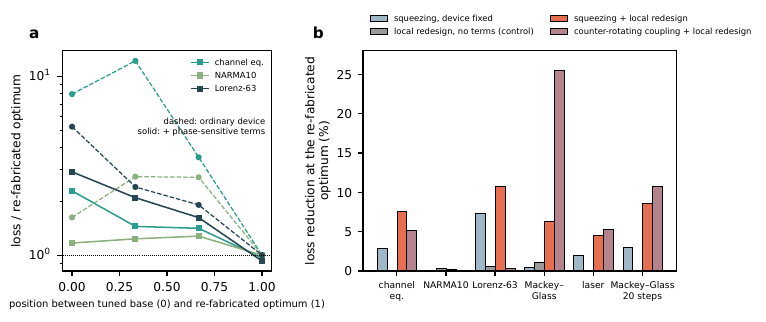

In [10]:
if RUN:
    for mode, ts in (('check', []), ('opt', ['nce', 'narma', 'lorenz', 'mg', 'laser', 'mg20']), ('decomp', ['nce', 'narma', 'lorenz', 'mg', 'laser', 'mg20']), ('path', ['nce', 'narma', 'lorenz']),
                     ('sqfix', ['nce', 'narma', 'lorenz', 'mg', 'laser', 'mg20', 'lorenz5', 'lorenz10', 'mg40', 'nce4', 'nce6']), ('sqfix2', ['nce', 'narma', 'lorenz', 'mg', 'laser', 'mg20', 'lorenz5', 'lorenz10', 'mg40', 'nce4', 'nce6']),
                     ('ordctl', ['lorenz5', 'lorenz10', 'mg40', 'nce4', 'nce6'])):
        subprocess.run([sys.executable, 'rev_ps.py', mode] + ts, check=True)
print(open('../paper/pstable.tex').read())
show('../paper/figs/figS_ps.pdf')

**Result.** The phase-sensitive terms do help at the re-fabricated optimum, modestly. Device fixed, continuous phase: 0.1–7.3 % (Lorenz 7.3 % from external squeezing at the photon budget, which the restricted protocol of Sec. 2.4, drive phase 0 or $\pi/2$ and a hard budget cut in the scan, rejected). Squeezing + local redesign: 4.6–10.8 % on every task but NARMA10, against ≤ 1.1 % for the same redesign without phase-sensitive terms. An independent counter-rotating coupling: up to 26 % (Mackey–Glass). Along the line from the tuned base to the re-fabricated device the terms lower the loss by 13–88 % but never reach the re-fabricated optimum: a large substitute for re-fabrication, a modest complement to it. On the difficulty ladders (table of section 6) the fixed-device gain is ≤ 7.3 % and decreases with difficulty; the co-design gain net of its control is 4.6–10.2 % on 8 of 11 variants with no trend.

## 5. Input-phase convention of the squeezed-detection study
The first revision used $\langle b_{\rm in}^2\rangle=-M^*$ in `expt.input_variance`. Input–output theory for $L_a=\sqrt\kappa(\mu a+\nu a^\dagger)$ gives $\langle b_{\rm in}^2\rangle=-\mu\nu=-M$, which is also $\langle a^2\rangle$ of the bath-only steady state (`expt.check_input_phase()`). The two agree for the $Q$ and $P$ settings used everywhere in the main text and differ only for rotated local oscillators; `rev_lo.py` and `rev_lo_diag.py` were rerun.

In [11]:
import expt; expt.check_input_phase()
print(open('../paper/lotable.tex').read())

check_input_phase ok
\begin{tabular}{lcccccccc}
\toprule
LO angles of the two settings & \multicolumn{2}{c}{NARMA10} & \multicolumn{2}{c}{Lorenz-63} & \multicolumn{2}{c}{channel eq.} & \multicolumn{2}{c}{Santa Fe laser}\\
 & $10^6$ & $10^7$ & $10^6$ & $10^7$ & $10^6$ & $10^7$ & $10^6$ & $10^7$\\
\midrule
$(Q,P)$, vacuum input noise & 17 & 27 & 7 & 15 & 50 & 63 & -7 & 1\\
$(Q,P)$, squeezed input noise & 17 & 27 & 9 & 14 & 50 & 63 & -13 & 1\\
$(X_{\phi_{\rm sq}},X_{\phi_{\rm sq}+\pi/2})$ & 16 & 27 & 6 & -2 & 50 & 62 & -1 & 2\\
$(X_{\phi_{\rm sq}},X_{\phi_{\rm sq}})$ & 1 & 14 & 3 & -11 & 40 & 55 & -67 & -67\\
\midrule
$V_{\rm in}$ at $(Q,\ P,\ \phi_{\rm sq},\ \phi_{\rm sq}+\pi/2)$ & \multicolumn{2}{c}{2.44, 0.63, 0.37, 2.70} & \multicolumn{2}{c}{1.45, 0.77, 0.63, 1.60} & \multicolumn{2}{c}{1.61, 1.48, 0.37, 2.72} & \multicolumn{2}{c}{0.70, 1.76, 0.51, 1.94}\\
\bottomrule
\end{tabular}


## Interpretation
* **Boundary artefact, confirmed.** With the paper's noiseless objective a wider box sends the optimum to vanishing drive (NARMA10, $\epsilon=0.01$, $\max\langle a^\dagger a\rangle\approx10^{-4}$) or a decoupled emitter (channel equalization): a relative 1 % precision makes a vanishing signal free. With the measurement-aware objective ($10^7$ passes, noise-matched ridge) the wide-box re-fabricated optima are interior for all five tasks and beat the squeezed tuned device on every task.
* **With the restricted protocol, squeezing adds little to a converged re-fabricated device:** ≤ 0.3 % on all five tasks (≤ 0.3 % also with $\Omega_a$, $g\cosh r$, $\epsilon_{\rm eff}$ pinned). The 9–22 % of the previous version were gains over optima cut short by the box; the same effect is visible here as the 15 % Lorenz gain on the 300-evaluation ordinary optimum.
* **Joint design:** at or above the ordinary optimum for four tasks; 7 % below it for channel equalization with weak squeezing, a gap that a local ordinary re-optimization from the joint device does not close. Lorenz with a relaxed photon budget (4, $N_c=16$): external squeezing adds about 4 % to a not fully converged device.
* **Phase-sensitive terms (section 7):** with continuous phases, squeezing adds up to 7.3 % on the re-fabricated device as built and 5–11 % with a local redesign (control ≤ 1.1 %); NARMA10 gains nothing.
* **Seeds:** tuned-drive gains 65 ± 3 % (channel equalization) and 26 ± 4 % (NARMA10) over eight fresh realizations.
* **Emitter efficiency:** $\eta_e=0.1$ costs a factor ≈ 4 in passes for a given precision; the channel-equalization gain at $10^7$ passes is 57 % instead of 63 %.
* **Readout model:** the bin model is 7–13 % conservative where the input is vacuum; with squeezed input the vacuum-noise version underestimates the cavity noise by 24–58 % (the input-noise version is again conservative), but the measured gains change by about one percentage point because the emitter channel dominates.
* **Convention fix:** $\langle b_{\rm in}^2\rangle=-M$; only rotated-LO results of the squeezed-detection study change.